In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
from joblib import parallel_backend

# Load model and scaler
rf_model = joblib.load('../models/rf_ids_model.pkl')
scaler   = joblib.load('../models/scaler.pkl')

# Load adversarial data from Phase 3
X_adv_fgsm = np.load('../data/X_adv_fgsm.npy')
X_sample   = np.load('../data/X_original_sample.npy')
y_sample   = np.load('../data/y_sample.npy')

# Load full test set
X_test = np.load('../data/X_test.npy')
y_test = np.load('../data/y_test.npy')

# Load evasion summary
with open('../results/fgsm_summary.json', 'r') as f:
    summary = json.load(f)

print("All data loaded")
print(f"Original samples:     {X_sample.shape}")
print(f"Adversarial samples:  {X_adv_fgsm.shape}")
print(f"Evasion rate (Phase3): {summary['evasion_rate']}%")

All data loaded
Original samples:     (100, 41)
Adversarial samples:  (100, 41)
Evasion rate (Phase3): 100.0%


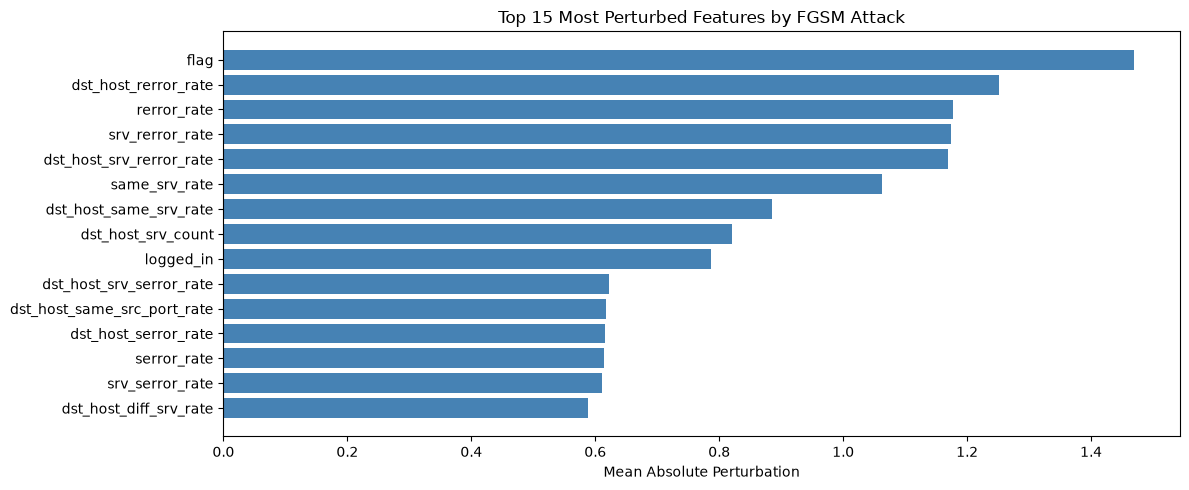


Top 10 most perturbed features:
   1. flag                                1.469943
   2. dst_host_rerror_rate                1.250606
   3. rerror_rate                         1.177603
   4. srv_rerror_rate                     1.173171
   5. dst_host_srv_rerror_rate            1.169712
   6. same_srv_rate                       1.063242
   7. dst_host_same_srv_rate              0.885727
   8. dst_host_srv_count                  0.820960
   9. logged_in                           0.786319
  10. dst_host_srv_serror_rate            0.622211


In [14]:
feature_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate'
]

# Calculate per-feature perturbation
perturbation       = np.abs(X_adv_fgsm - X_sample)
mean_perturbation  = perturbation.mean(axis=0)
total_perturbation = perturbation.sum(axis=0)

# Top 15 most perturbed features
top15_idx  = np.argsort(mean_perturbation)[::-1][:15]
top15_feat = [feature_names[i] for i in top15_idx]
top15_vals = mean_perturbation[top15_idx]

plt.figure(figsize=(12, 5))
bars = plt.barh(top15_feat[::-1], top15_vals[::-1], color='steelblue')
plt.xlabel('Mean Absolute Perturbation')
plt.title('Top 15 Most Perturbed Features by FGSM Attack')
plt.tight_layout()
plt.savefig('../results/top15_perturbed_features.png', dpi=150)
plt.show()

print("\nTop 10 most perturbed features:")
for i, (feat, val) in enumerate(zip(top15_feat[:10], top15_vals[:10])):
    print(f"  {i+1:2}. {feat:<35} {val:.6f}")

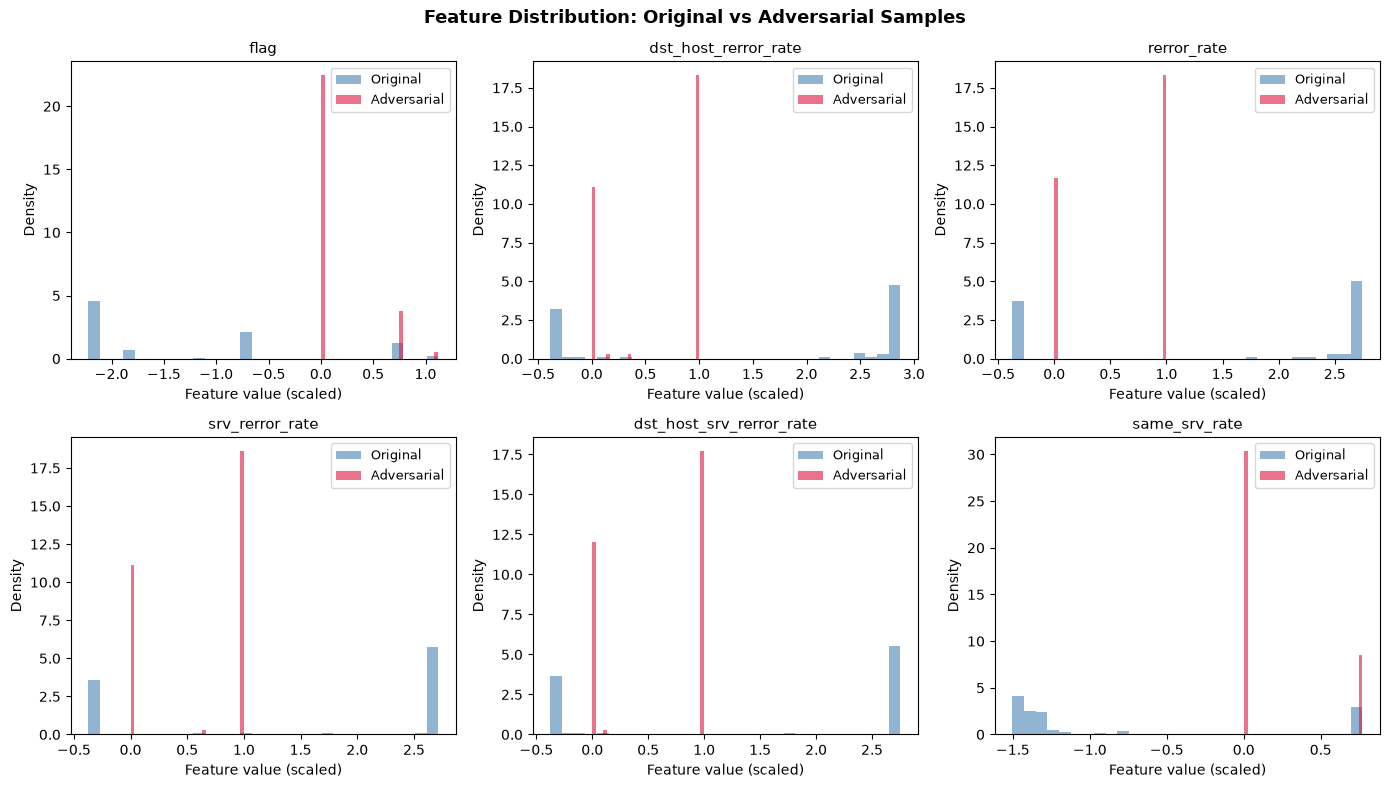

Saved to results/


In [15]:
# Compare original vs adversarial for top 6 most perturbed features
top6_idx  = np.argsort(mean_perturbation)[::-1][:6]
top6_feat = [feature_names[i] for i in top6_idx]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for plot_i, feat_i in enumerate(top6_idx):
    ax = axes[plot_i]
    
    orig_vals = X_sample[:, feat_i]
    adv_vals  = X_adv_fgsm[:, feat_i]
    
    ax.hist(orig_vals, bins=30, alpha=0.6, 
            label='Original', color='steelblue', density=True)
    ax.hist(adv_vals,  bins=30, alpha=0.6, 
            label='Adversarial', color='crimson', density=True)
    
    ax.set_title(feature_names[feat_i], fontsize=11)
    ax.set_xlabel('Feature value (scaled)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distribution: Original vs Adversarial Samples', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/feature_distribution_shift.png', dpi=150)
plt.show()
print("Saved to results/")

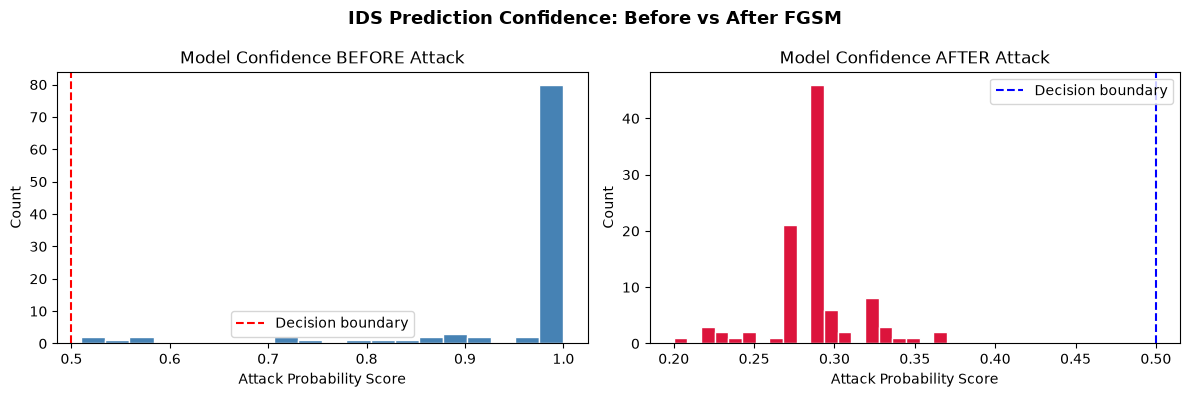

Mean attack confidence BEFORE: 0.9540
Mean attack confidence AFTER:  0.2873
Confidence drop:               0.6667


In [16]:
# Get prediction probabilities before and after
with parallel_backend('threading', n_jobs=1):
    prob_before = rf_model.predict_proba(X_sample)[:, 1]
    prob_after  = rf_model.predict_proba(X_adv_fgsm)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
axes[0].hist(prob_before, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Decision boundary')
axes[0].set_xlabel('Attack Probability Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Model Confidence BEFORE Attack')
axes[0].legend()

# After
axes[1].hist(prob_after, bins=20, color='crimson', edgecolor='white')
axes[1].axvline(x=0.5, color='blue', linestyle='--', label='Decision boundary')
axes[1].set_xlabel('Attack Probability Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Model Confidence AFTER Attack')
axes[1].legend()

plt.suptitle('IDS Prediction Confidence: Before vs After FGSM', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/confidence_shift.png', dpi=150)
plt.show()

print(f"Mean attack confidence BEFORE: {prob_before.mean():.4f}")
print(f"Mean attack confidence AFTER:  {prob_after.mean():.4f}")
print(f"Confidence drop:               {prob_before.mean() - prob_after.mean():.4f}")

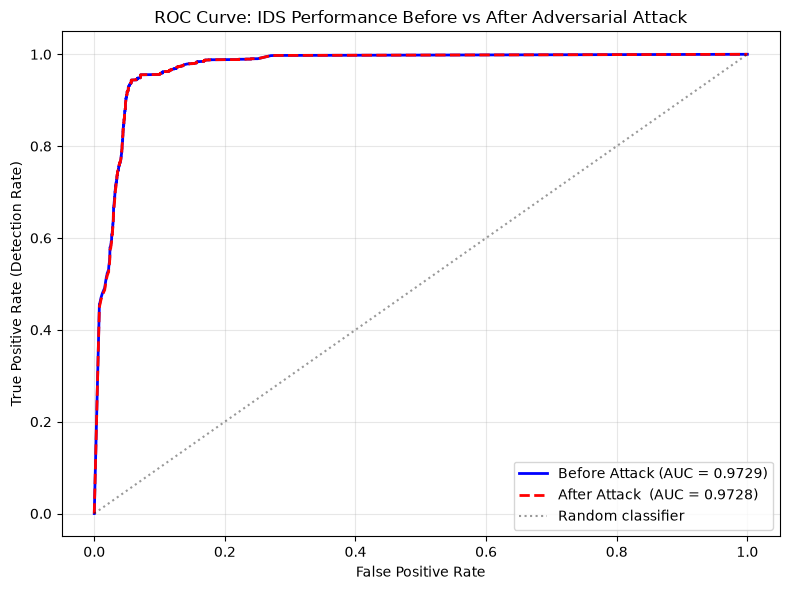

AUC Before Attack: 0.9729
AUC After Attack:  0.9728
AUC Degradation:   0.0001


In [17]:
# ROC curve shows model performance across all thresholds
with parallel_backend('threading', n_jobs=1):
    prob_full_before = rf_model.predict_proba(X_test)[:, 1]

# Simulate "after attack" on full test set by replacing
# attack samples with adversarial versions
X_test_adv = X_test.copy()
attack_indices = np.where(y_test == 1)[0][:len(X_adv_fgsm)]
X_test_adv[attack_indices] = X_adv_fgsm

with parallel_backend('threading', n_jobs=1):
    prob_full_after = rf_model.predict_proba(X_test_adv)[:, 1]

# Calculate ROC curves
fpr_b, tpr_b, _ = roc_curve(y_test, prob_full_before)
fpr_a, tpr_a, _ = roc_curve(y_test, prob_full_after)
auc_before       = auc(fpr_b, tpr_b)
auc_after        = auc(fpr_a, tpr_a)

plt.figure(figsize=(8, 6))
plt.plot(fpr_b, tpr_b, 'b-', linewidth=2, 
         label=f'Before Attack (AUC = {auc_before:.4f})')
plt.plot(fpr_a, tpr_a, 'r--', linewidth=2, 
         label=f'After Attack  (AUC = {auc_after:.4f})')
plt.plot([0,1],[0,1], 'k:', alpha=0.4, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Detection Rate)')
plt.title('ROC Curve: IDS Performance Before vs After Adversarial Attack')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/roc_curve_degradation.png', dpi=150)
plt.show()

print(f"AUC Before Attack: {auc_before:.4f}")
print(f"AUC After Attack:  {auc_after:.4f}")
print(f"AUC Degradation:   {auc_before - auc_after:.4f}")

In [19]:
with parallel_backend('threading', n_jobs=1):
    y_pred_clean = rf_model.predict(X_test)
    y_pred_adv   = rf_model.predict(X_test_adv)

acc_clean = accuracy_score(y_test, y_pred_clean)
acc_adv   = accuracy_score(y_test, y_pred_adv)

print("=" * 55)
print("   ADVERSARIAL ATTACK RESEARCH SUMMARY")
print("=" * 55)
print(f"\n  TARGET MODEL:        Random Forest IDS")
print(f"  DATASET:             NSL-KDD")
print(f"  ATTACK METHOD:       FGSM (white-box)")
print(f"  ATTACK SAMPLES:      {len(X_adv_fgsm)}")
print(f"\n  --- BASELINE PERFORMANCE ---")
print(f"  Overall Accuracy:    {acc_clean*100:.2f}%")
print(f"  AUC Score:           {auc_before:.4f}")
print(f"\n  --- POST-ATTACK PERFORMANCE ---")
print(f"  Overall Accuracy:    {acc_adv*100:.2f}%")
print(f"  AUC Score:           {auc_after:.4f}")
print(f"\n  --- ATTACK EFFECTIVENESS ---")
print(f"  Evasion Rate:        {summary['evasion_rate']}%")
print(f"  AUC Degradation:     {auc_before - auc_after:.4f}")
print(f"  Confidence Drop:     {prob_before.mean() - prob_after.mean():.4f}")
print(f"  Min epsilon needed:  0.05")
print("=" * 55)

# Save full summary
full_summary = {
    'model':           'Random Forest',
    'dataset':         'NSL-KDD',
    'attack':          'FGSM',
    'baseline_acc':    round(acc_clean * 100, 2),
    'post_attack_acc': round(acc_adv * 100, 2),
    'auc_before':      round(auc_before, 4),
    'auc_after':       round(auc_after, 4),
    'auc_degradation': round(auc_before - auc_after, 4),
    'evasion_rate':    summary['evasion_rate'],
    'confidence_drop': round(float(prob_before.mean() - prob_after.mean()), 4)
}

with open('../results/full_research_summary.json', 'w') as f:
    json.dump(full_summary, f, indent=2)

print("\nFull summary saved to results/full_research_summary.json")

   ADVERSARIAL ATTACK RESEARCH SUMMARY

  TARGET MODEL:        Random Forest IDS
  DATASET:             NSL-KDD
  ATTACK METHOD:       FGSM (white-box)
  ATTACK SAMPLES:      100

  --- BASELINE PERFORMANCE ---
  Overall Accuracy:    77.31%
  AUC Score:           0.9729

  --- POST-ATTACK PERFORMANCE ---
  Overall Accuracy:    77.00%
  AUC Score:           0.9728

  --- ATTACK EFFECTIVENESS ---
  Evasion Rate:        100.0%
  AUC Degradation:     0.0001
  Confidence Drop:     0.6667
  Min epsilon needed:  0.05

Full summary saved to results/full_research_summary.json
